In [13]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("/home/vsingh/projects/chi-26/Evaluation/CHI-Evaluation - sub-group-comparison.csv")
print(df.shape)
df.head()

(100, 50)


,The tool would be valuable for my day-to-day HR tasks.,The tool's features are useful and relevant to my professional responsibilities.,The tool would improve the efficiency of my work.,The tool would help me make better decisions.,I would use this tool frequently if it were available to me.,I would recommend this tool to other HR Managers.,The tool reveals HR perspectives and topics that were previously unknown to me.,The tool improves my understanding of global HRM perspectives on managing gig workers.,The tool helps me compare my local practices against global benchmarks for gig worker fairness.,I can apply the information from the tool to improve gig work conditions.,...,What gender do you mostly identify with?,What ethnicity do you mostly identify with?,What is your current age in years? Please enter a whole number.,What is the highest level of education you have completed?,Do you have a disability? (Either a physical or cognitive disability),Have you been formally identified by your organization as a high potential employee?,Please enter your total years of experience as an HR professional:,How many employees does your company have?,What industry does your company operate in?,What percentage of your workforce is gig workers?
0,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat disagree,Somewhat agree,Somewhat agree,Somewhat agree,...,Male,White/Caucasian/European,32,University - Bachelors Degree,No,Yes,6.0,5000,Healthcare,11-25%
1,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Neither agree nor disagree,Somewhat agree,...,Male,White/Caucasian/European,30,Vocational or Similar,No,No,6.0,120000,Goverment,0-10%
2,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,...,Male,"Hispanic/Latino/Latinx, non-white",24,University - Bachelors Degree,No,No,3.0,14,MEXICO,11-25%
3,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,...,Female,"Hispanic/Latino/Latinx, non-white",21,Primary,Yes,Yes,1.0,2000,petcare,11-25%
4,Strongly agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,...,Female,White/Caucasian/European,33,Vocational or Similar,No,Yes,7.0,80000,retail,0-10%


In [37]:
# --- Style Setup for Academic Figures ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

In [38]:
# Define the mapping of old column names to new column names
column_name_mapping = {
    'The tool would be valuable for my day-to-day HR tasks.': 'valuable',
    'The tool\'s features are useful and relevant to my professional responsibilities.': 'useful',
    'The tool would improve the efficiency of my work.': 'improve_efficiency',
    'The tool would help me make better decisions.': 'better_decisions',
    'I would use this tool frequently if it were available to me.': 'frequent_use',
    'I would recommend this tool to other HR Managers.': 'recommend',
    'I can apply the information from the tool to improve gig work conditions.': 'improve_gig_work_conditions',
    'The tool gives me new insights about my organizational role in gig worker fairness.': 'gig_worker_fairness',
    'The tool supports evidence-based decision-making for HR policy changes.': 'evidence_based_decision_making'
}

In [39]:
# Apply the renaming to your DataFrame
df = df.rename(columns=column_name_mapping)


In [40]:
likert_map = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,}


In [41]:
df = df.replace(likert_map)

/tmp/ipykernel_781070/3564872603.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(likert_map)


In [42]:
# --- 2. CLEAN AND PREPARE THE EXPERIENCE VARIABLE ---
# Ensure the experience column is numeric, coercing errors to NaN
df['Please enter your total years of experience as an HR professional:'] = pd.to_numeric(
    df['Please enter your total years of experience as an HR professional:'], errors='coerce'
)

# Define the experience group based on the threshold
df['exp_group'] = np.where(
    df['Please enter your total years of experience as an HR professional:'] <= 5,
    'Experience(<=5 yrs)',
    'Experience(5+ yrs)'
)

# Check group sizes
group_counts = df['exp_group'].value_counts()
print("Number of participants per group:")
print(group_counts)
print("\n")


Number of participants per group:
exp_group
Experience(5+ yrs)     51
Experience(<=5 yrs)    49
Name: count, dtype: int64




In [43]:
# --- 3. DEFINE KEY VARIABLES FOR COMPARISON ---
key_variables = ['valuable', 'useful', 'frequent_use', 'improve_efficiency', 'better_decisions', 'improve_gig_work_conditions', 'gig_worker_fairness', 'evidence_based_decision_making', 'recommend'] # Add all your renamed columns here

In [44]:
# --- 4. PERFORM SUBGROUP COMPARISONS ---
results_list = []

for var in key_variables:
    # Extract data for each group, handling potential NaN values
    group_novice = df[df['exp_group'] == 'Experience(<=5 yrs)'][var].dropna()
    group_expert = df[df['exp_group'] == 'Experience(5+ yrs)'][var].dropna()
    
    # Skip if one group has no data
    if group_novice.empty or group_expert.empty:
        print(f"Warning: Not enough data for {var}. Skipping.")
        continue
        
    # Descriptive Statistics
    mean_novice = group_novice.mean()
    std_novice = group_novice.std()
    mean_expert = group_expert.mean()
    std_expert = group_expert.std()
    
    # Independent T-Test (Welch's t-test, does not assume equal variances)
    t_stat, p_val = stats.ttest_ind(group_novice, group_expert, equal_var=False)
    
    # Calculate Cohen's d for effect size
    pooled_std = np.sqrt((std_novice**2 + std_expert**2) / 2)
    cohens_d = (mean_novice - mean_expert) / pooled_std
    
    # Interpret effect size
    effect_size_str = "Negligible"
    if abs(cohens_d) >= 0.8:
        effect_size_str = "Large"
    elif abs(cohens_d) >= 0.5:
        effect_size_str = "Medium"
    elif abs(cohens_d) >= 0.2:
        effect_size_str = "Small"
        
    # Determine significance asterisk
    sig = ""
    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    
    # Append results
    results_list.append({
        'Variable': var,
        'Less Experienced Mean': f"{mean_novice:.3f}",
        'Less Experienced Std': f"{std_novice:.3f}",
        'More Experienced Mean': f"{mean_expert:.3f}",
        'More Experienced Std': f"{std_expert:.3f}",
        't': f"{t_stat:.3f}",
        'p': f"{p_val:.4f}{sig}",
        "Cohen's d": f"{cohens_d:.3f}",
        'Effect Size': effect_size_str
    })

# Create and display the results DataFrame
results_df = pd.DataFrame(results_list)
print("--- RESULTS OF SUBGROUP COMPARISON (Novice vs. Experienced HR Professionals) ---")
print(results_df.to_string(index=False))
print("\n" + "Note: *** p < .001, ** p < .01, * p < .05")
print("\n")


--- RESULTS OF SUBGROUP COMPARISON (Novice vs. Experienced HR Professionals) ---
                      Variable Less Experienced Mean Less Experienced Std More Experienced Mean More Experienced Std     t      p Cohen's d Effect Size
                      valuable                 4.184                0.782                 4.039                1.148 0.738 0.4625     0.147  Negligible
                        useful                 4.265                0.785                 4.078                1.129 0.965 0.3374     0.192  Negligible
                  frequent_use                 4.082                0.812                 3.980                1.257 0.480 0.6323     0.096  Negligible
            improve_efficiency                 4.122                0.857                 4.039                1.095 0.424 0.6724     0.085  Negligible
              better_decisions                 4.286                0.816                 4.059                0.988 1.254 0.2130     0.250       Small
   impr

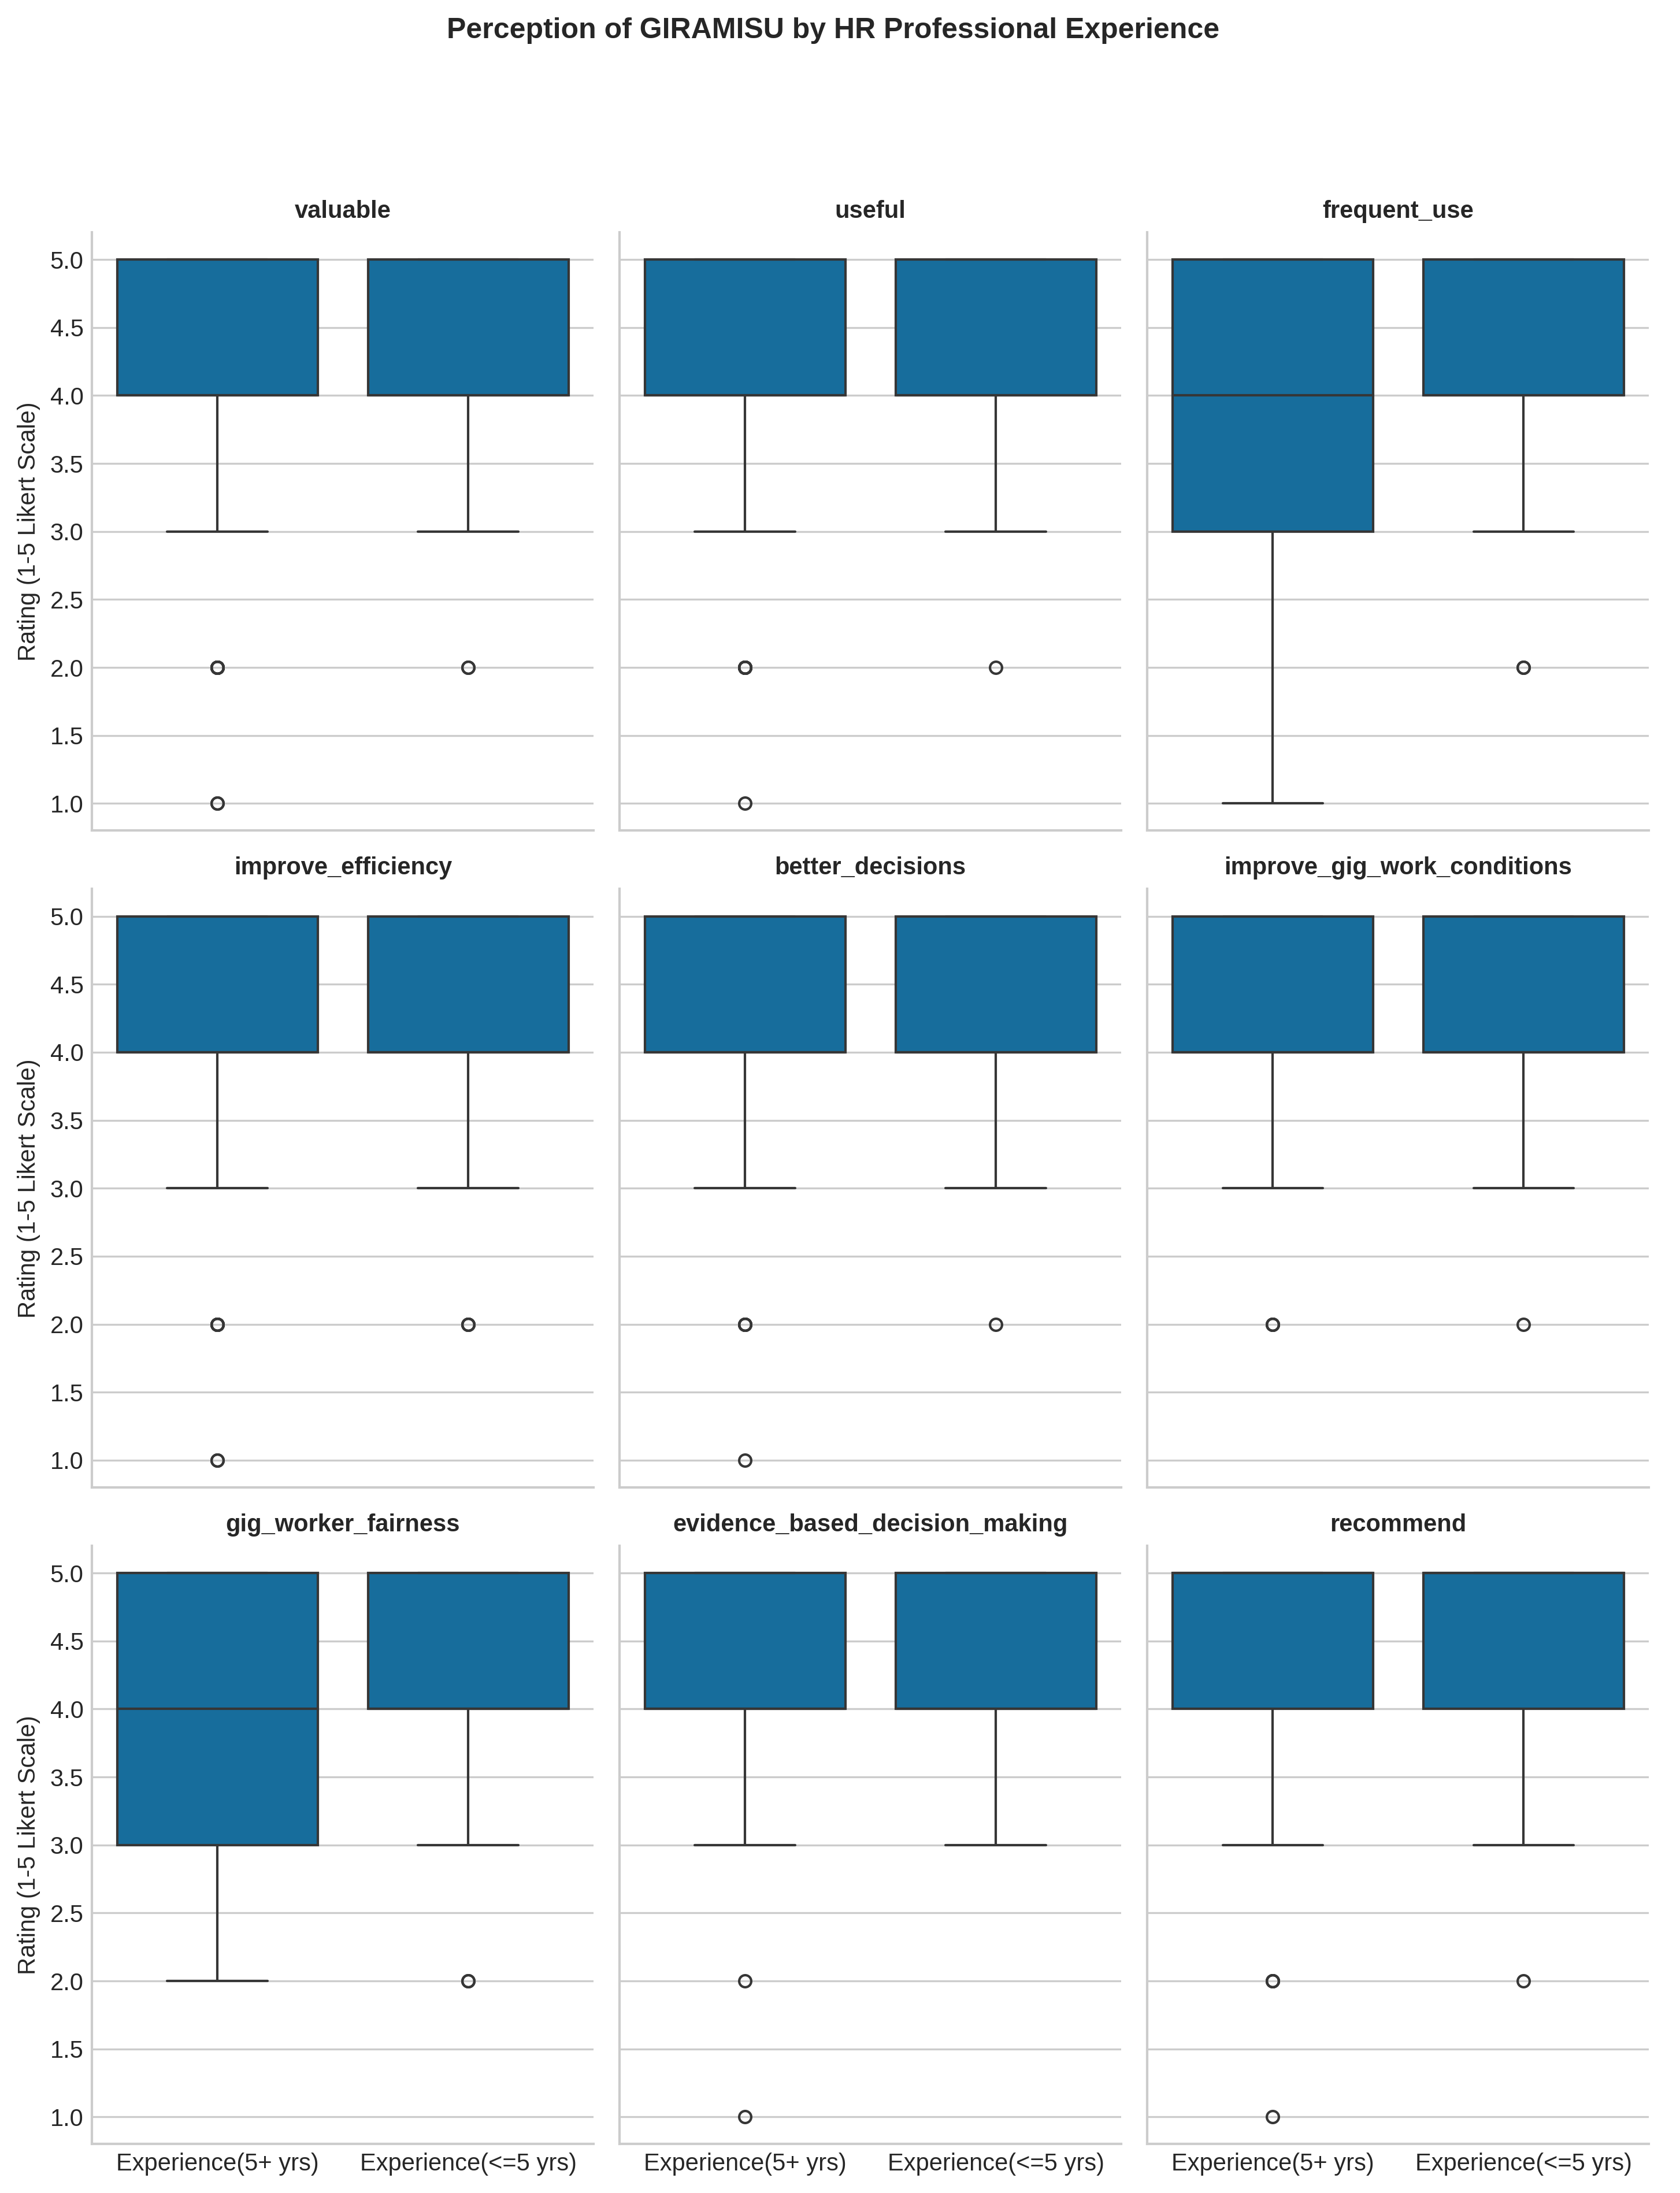

In [46]:
# --- 5. VISUALIZATION ---
# Melt the dataframe to make it suitable for seaborn plotting
df_melted = df.melt(
    id_vars=['exp_group'],
    value_vars=key_variables,
    var_name='Survey_Item',
    value_name='Rating'
)

# Create a grid of boxplots
g = sns.catplot(
    data=df_melted,
    x='exp_group',
    y='Rating',
    col='Survey_Item',
    kind='box',
    col_wrap=3,
    height=4,
    aspect=0.8,
    sharey=True,
    sharex=True
)

# Set titles and labels
g.fig.suptitle('Perception of GIRAMISU by HR Professional Experience', fontweight='bold', y=1.05)
g.set_axis_labels("", "Rating (1-5 Likert Scale)")
g.set_titles("{col_name}")

# Annotate with significance from results
for ax, var in zip(g.axes.flat, key_variables):
    # Find the result for this variable
    try:
        result = results_df[results_df['Variable'] == var].iloc[0]
        p_val_str = result['p']
        d_val = float(result["Cohen's d"])
        # Add annotation if p < 0.05
        if '*' in p_val_str:
            ax.text(0.5, 4.8, f"p = {p_val_str}\nd = {d_val:.2f}", 
                   ha='center', va='center', fontsize=9,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    except IndexError:
        pass # Skip if no result was found for this variable

plt.tight_layout()
plt.savefig('chi_subgroup_comparison_exp.png', dpi=300, bbox_inches='tight')
plt.show()